# Chapter 12. LLM이 만든 분석 코드를 검증하는 방법

이 Notebook은 "Chapter 12 실습 진행 가이드. LLM이 만든 분석 코드를 검증하는 방법"을 따라가면서, 실제로 AI(LLM)에게 무엇을 물어봤고 어떤 설명을 이해했고 실행 결과가 어떻게 나왔는지를 한 단계씩 남긴 기록입니다.

지금까지는 **내가 코드를 짜고 그 결과를 검증**했다면, 이번에는 순서가 바뀝니다. LLM이 만들어 준 코드를 받았을 때 **그 코드를 바로 실행하지 않고** 먼저 읽고, 검증하고, 사람이 승인한 뒤에만 제한된 환경에서 실행하는 연습입니다.

이번 장에서 계속 기억할 세 문장입니다.

- 코드 실행 성공 ≠ 분석 타당성
- 정적 스캔 0건 ≠ 코드 안전
- 자동 검증 PASS ≠ 실행 승인

`Generated Code 읽기 → processed 입력 확인 → 필수 컬럼/PK/FK 검증 → merge·completed·총합 검증 → AST Static Scan → 회귀·분류 Feature Contract → Sandbox/Package 검토 → Execution Gate → 사람 승인(APPROVE/REVISE/BLOCK) → 승인된 코드만 제한 실행 → 실행 후 재검증 → 사람 수정 기록`

## 제출 정보
- 이름: 조영우
- GitHub ID: `cyw0927`
- 작성일: 2026-10-06
- 최종 Notebook URL:

```text
https://github.com/cyw0927/-llm-data-analysis-course/blob/main/assignments/chapter12/chapter12.ipynb
```

## 실습 0. 실행 환경 확인하고 processed 입력 확인하기

### AI에게 질문

> Chapter12 검증은 raw 데이터가 아니라 processed 데이터에서 시작한다고 합니다. 입력 파일이 없을 때 raw로 자동으로 바꿔서 돌리면 편할 것 같은데, 왜 안 된다고 하는 건가요?

### 초보자 상세 설명

가이드에 이렇게 되어 있었습니다.

> Chapter 12는 processed 입력이 없을 때 raw로 자동 fallback하지 않습니다. processed 없음 → FAIL → preprocess_data.py 실행

처음에는 "있는 파일로 대신 돌리면 되는데 왜?"라고 생각했습니다. 그런데 생각해 보니, 검증은 **"어떤 입력으로 검증했는지"가 고정되어 있어야** 의미가 있습니다. 입력이 조용히 raw로 바뀌면 중복·결측·FK 오류가 그대로 섞인 데이터로 검증했는데도 PASS처럼 보일 수 있습니다. 그래서 입력이 없으면 대신 돌리지 않고 **멈추는(FAIL)** 쪽이 맞습니다.

이 저장소에는 공식 저장소의 `preprocess_data.py` 대신 Chapter07 때부터 써온 `scripts/rebuild_processed_data.py`로 `data/processed/*_clean.csv` 4개를 이미 만들어 두었습니다. 이번 실습에서는 그 파일이 있는지 먼저 확인하고, 일부러 없는 폴더를 가리켰을 때 정말로 멈추는지도 확인합니다.

이번에도 공통 검증 코드는 `src/llm_code_validation.py`, `src/llm_code_validation_policy.py`로 만들어 두고 Notebook에서는 불러다 씁니다.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image


def find_project_root(start: Path) -> Path:
    """현재 Notebook 위치와 상관없이 저장소 루트를 찾습니다."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
CH12_DIR = PROJECT_ROOT / "assignments" / "chapter12"
GENERATED_DIR = CH12_DIR / "generated_code"
IMAGE_DIR = CH12_DIR / "images"
SANDBOX_DIR = CH12_DIR / "_sandbox"
STUDENT_REPORT_DIR = REPORT_DIR / "ch12_student"

print("Python 실행 파일:", sys.executable)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("pandas 버전:", pd.__version__)

Python 실행 파일: C:\Users\dkrak\AppData\Local\Programs\Python\Python314\python.exe
PROJECT_ROOT: C:\dev\llm-data-analysis-course
pandas 버전: 3.0.5


In [2]:
from src.llm_code_validation import DATASET_FILES, load_validation_data

for name, file_name in DATASET_FILES.items():
    path = PROCESSED_DIR / file_name
    print(f"{file_name:22s} 존재: {path.exists()}   크기: {path.stat().st_size:,} bytes")

# 일부러 없는 폴더를 가리켜서, raw로 몰래 대체하지 않고 멈추는지 확인
try:
    load_validation_data(PROJECT_ROOT / "data" / "no_such_processed_folder")
except FileNotFoundError as error:
    print("\n[입력이 없을 때] 멈춤(FAIL)")
    print(str(error)[:90], "...")

customers_clean.csv    존재: True   크기: 5,641 bytes
products_clean.csv     존재: True   크기: 4,103 bytes
orders_clean.csv       존재: True   크기: 16,530 bytes
order_items_clean.csv  존재: True   크기: 20,563 bytes

[입력이 없을 때] 멈춤(FAIL)
processed 입력이 없습니다. raw로 대체하지 않고 중단합니다. 먼저 전처리 스크립트를 실행하세요. 누락 파일: C:\dev\llm-data-analysi ...


### 실습 0 결과 확인 및 정리

### 결과 관찰
- `PROJECT_ROOT`가 저장소 최상위 폴더로 나왔고, 실행 파일은 `Python314`(이 PC에서 scikit-learn이 막히지 않는 Python 3.14 커널)였습니다.
- `data/processed/`에 4개 파일이 모두 있었습니다: `customers_clean.csv`(5,641 bytes), `products_clean.csv`(4,103), `orders_clean.csv`(16,530), `order_items_clean.csv`(20,563).
- 일부러 없는 폴더를 가리키자 `FileNotFoundError`가 나면서 "processed 입력이 없습니다. raw로 대체하지 않고 중단합니다."라는 메시지로 **멈췄습니다.**

### 나의 해석과 판단
검증에서 raw fallback을 허용하지 않는 이유를 한 문장으로 적으면: **"어떤 입력으로 검증했는지가 조용히 바뀌면, 중복·결측·FK 오류가 섞인 데이터로 검증하고도 PASS처럼 보일 수 있기 때문"** 입니다.

### 한계와 추가 확인 사항
이번 장의 공통 검증 코드(`src/llm_code_validation.py` 등)는 공식 저장소 파일을 받아 쓴 것이 아니라, 가이드에 적힌 함수 이름과 규칙에 맞춰 이 저장소에 **직접 만든 것**입니다. 그래서 공식 코드와 세부 규칙(예: 정적 스캔이 잡는 패턴)이 다를 수 있습니다.

## 실습 1. Generated Code를 실행하지 않고 먼저 읽기

### AI에게 질문

> 주문 데이터에서 카테고리별 매출 합계를 구해서 CSV로 저장하는 pandas 코드를 만들어 주세요. 파일은 data/processed에 있는 orders, order_items, products를 쓰면 됩니다.

### 초보자 상세 설명

LLM이 위 질문에 대한 답으로 코드를 하나 만들어 줬다고 가정하고, 그 코드를 `generated_code/draft_category_sales.py`에 저장해 두었습니다. (이 코드는 일부러 **그대로 믿으면 안 되는 부분**이 섞여 있는 초안입니다. 이 장의 핵심이 "생성 코드는 완성된 답이 아니라 검토되지 않은 초안"이라서, 어디가 문제인지 스스로 찾아내는 연습을 하려는 것입니다.)

가이드는 실행하기 **전에** 이런 질문들을 먼저 하라고 했습니다.

- 어떤 파일을 읽고, 어떤 파일을 만들거나 지우는가?
- 어떤 dataset·column을 쓰고, 어떤 key로 merge하는가?
- 어떤 주문 상태를 포함하는가? 금액 계산식은 무엇인가?
- 네트워크 요청, OS/Shell 명령, subprocess, package 설치, Secret 읽기가 있는가?

아직 **실행하지 않습니다.** 아래 셀은 파일을 "읽어서 화면에 보여주기만" 합니다.

In [3]:
draft_path = GENERATED_DIR / "draft_category_sales.py"
draft_code = draft_path.read_text(encoding="utf-8")

for line_no, line in enumerate(draft_code.splitlines(), start=1):
    print(f"{line_no:2d} | {line}")

print("\n※ 위 코드는 읽기만 했습니다. 실행하지 않았습니다.")

 1 | import pandas as pd
 2 | 
 3 | orders = pd.read_csv("data/processed/orders_clean.csv")
 4 | items = pd.read_csv("data/processed/order_items_clean.csv")
 5 | products = pd.read_csv("data/processed/products_clean.csv")
 6 | 
 7 | df = items.merge(products, on="product_id", how="left")
 8 | df = df.merge(orders, on="order_id", how="left")
 9 | 
10 | df["amount"] = df["quantity"] * df["price"]
11 | 
12 | result = (
13 |     df.groupby("category")["amount"]
14 |     .sum()
15 |     .sort_values(ascending=False)
16 |     .reset_index()
17 | )
18 | 
19 | print(result)
20 | result.to_csv("C:/reports/category_sales.csv", index=False)

※ 위 코드는 읽기만 했습니다. 실행하지 않았습니다.


### 실습 1 결과 확인 및 정리

## 생성 코드가 하려는 일
LLM에게 "카테고리별 매출 합계를 CSV로 저장"하라고 시킨 초안입니다. 흐름은 다음과 같았습니다.

`입력(orders / order_items / products CSV 3개 읽기)` → `order_items와 products를 left merge` → `그 결과에 orders를 left merge` → `amount = quantity × products.price 계산` → `category별 합계` → `화면 출력` → `C:/reports/category_sales.csv로 저장`

## Read Before Run - 분석 논리 점검 (실행 전에 읽고 찾은 것)
| 확인 질문 | 읽어서 확인한 내용 | 판단 |
| --- | --- | --- |
| 어떤 dataset / column을 쓰는가 | orders, order_items, products / quantity, price, category 등 | 사용 컬럼 자체는 데이터에 있는 것들 |
| 어떤 key로 merge하는가 | product_id, order_id | key 자체는 맞지만 **고유성 확인 없음** |
| merge 검증이 있는가 | `how="left"`만 있고 `validate`, `indicator`, 행 수 확인이 **없음** | 위험 |
| 어떤 주문 상태를 포함하는가 | orders를 merge하지만 `order_status`는 **한 번도 쓰지 않음** (7~8번째 줄) | **위험: 취소/환불 주문이 매출에 섞임** |
| 금액 계산식은 무엇인가 | `quantity * price` (products.price) | `line_total`을 쓰지 않음, 가격이 바뀌면 과거 주문 금액이 틀려질 수 있음 |

## Read Before Run - 실행 안전 점검
| 확인 질문 | 읽어서 확인한 내용 |
| --- | --- |
| 읽는 파일 | `data/processed/` 안의 CSV 3개 (상대 경로) |
| 생성·수정·삭제하는 파일 | `C:/reports/category_sales.csv` **절대 경로**에 저장 → 같은 이름이 있으면 덮어쓸 수 있음 |
| 네트워크 요청 / OS·Shell 명령 / subprocess | 없음 |
| 새 package 설치 요구 | 없음 (pandas만 사용) |
| Secret·환경변수·민감 경로 읽기 | 없음 |

### 나의 해석과 판단
읽기만 했는데도 **분석 쪽 문제 4가지**(상태 필터 없음, merge 검증 없음, line_total 대신 price 사용, 키 고유성 확인 없음)와 **실행 쪽 문제 1가지**(절대 경로로 파일 덮어쓰기 가능)를 찾았습니다. 아직 실행은 하지 않았습니다.

## 실습 2. 실제 스키마·PK·FK 검증하기

### AI에게 질문

> 코드를 검토하기 전에, 이 코드가 믿고 있는 데이터 구조(컬럼, 기본키, 외래키)가 실제 데이터와 맞는지부터 확인하고 싶습니다. 어떤 순서로 검증하면 되나요?

### 초보자 상세 설명

생성 코드는 "이 컬럼이 있겠지, 이 key는 고유하겠지"라고 **가정**하고 짜여 있습니다. 가정이 틀리면 merge에서 행이 늘어나거나 사라져도 에러 없이 숫자만 틀리게 나옵니다. 그래서 코드를 보기 전에 데이터가 실제로 그 가정을 만족하는지 먼저 확인합니다.

- 필수 컬럼이 다 있는가? (`order_items.order_item_id`도 포함)
- PK에 결측/중복이 없는가? (customers.customer_id, products.product_id, orders.order_id, order_items.order_item_id)
- FK가 부모 테이블에 다 있는가? (orders→customers, order_items→orders, order_items→products)

그리고 중요한 규칙 하나: 필수 입력이 없으면 목록에서 **조용히 빼고 넘어가지 않고**, FAIL로 기록한 뒤 `assert_validation_ready`가 멈추게 합니다.

In [4]:
from src.llm_code_validation import (
    assert_validation_ready,
    build_dataset_inventory,
    load_validation_data,
    validate_primary_keys,
    validate_relationship_keys,
    validate_required_columns,
)

datasets = load_validation_data(PROCESSED_DIR)
inventory = build_dataset_inventory(datasets)
required_column_check = validate_required_columns(datasets)
primary_key_check = validate_primary_keys(datasets)
relationship_check = validate_relationship_keys(datasets)

display(inventory[["dataset", "file", "rows", "columns"]])
display(required_column_check)
display(primary_key_check)
display(relationship_check)

assert_validation_ready(required_column_check, primary_key_check, relationship_check)
print("스키마/PK/FK 검증: 모두 PASS (assert_validation_ready 통과)")

,dataset,file,rows,columns
0,customers,customers_clean.csv,150,6
1,products,products_clean.csv,100,4
2,orders,orders_clean.csv,300,7
3,order_items,order_items_clean.csv,764,6


,dataset,required_count,missing_columns,status
0,customers,5,-,PASS
1,products,3,-,PASS
2,orders,5,-,PASS
3,order_items,6,-,PASS


,dataset,primary_key,missing,duplicates,status
0,customers,customer_id,0,0,PASS
1,products,product_id,0,0,PASS
2,orders,order_id,0,0,PASS
3,order_items,order_item_id,0,0,PASS


,relationship,parent_key_unique,fk_missing,orphan_rows,status
0,orders.customer_id -> customers.customer_id,True,0,0,PASS
1,order_items.order_id -> orders.order_id,True,0,0,PASS
2,order_items.product_id -> products.product_id,True,0,0,PASS


스키마/PK/FK 검증: 모두 PASS (assert_validation_ready 통과)


In [5]:
# fail-fast가 실제로 동작하는지: order_item_id 컬럼을 일부러 뺀 복사본으로 확인 (원본은 건드리지 않음)
broken = {name: df.copy() for name, df in datasets.items()}
broken["order_items"] = broken["order_items"].drop(columns=["order_item_id"])

broken_required = validate_required_columns(broken)
display(broken_required)
try:
    assert_validation_ready(broken_required, validate_primary_keys(broken), validate_relationship_keys(broken))
except ValueError as error:
    print("멈춤(fail-fast):", str(error).splitlines()[0])

,dataset,required_count,missing_columns,status
0,customers,5,-,PASS
1,products,3,-,PASS
2,orders,5,-,PASS
3,order_items,6,order_item_id,FAIL


멈춤(fail-fast): 스키마/키 검증 실패:


### 실습 2 결과 확인 및 정리

### 결과 관찰
- 4개 dataset의 행 수: customers 150, products 100, orders 300, order_items 764.
- 필수 컬럼 검증: 4개 dataset 모두 PASS (`order_items.order_item_id` 포함, 6개 필수 컬럼).
- PK 검증: customers.customer_id / products.product_id / orders.order_id / order_items.order_item_id 모두 결측 0, 중복 0.
- FK 검증: `orders.customer_id → customers`, `order_items.order_id → orders`, `order_items.product_id → products` 모두 부모 key 고유, FK 결측 0, 부모에 없는 행(orphan) 0.
- fail-fast 확인: `order_item_id` 컬럼을 일부러 뺀 복사본에서는 required_column_check가 `FAIL`로 나왔고 `assert_validation_ready`가 `ValueError`로 멈췄습니다. (원본 데이터는 건드리지 않았습니다.)

### 나의 해석과 판단
이 데이터는 생성 코드가 믿는 가정(key 고유, FK 연결)을 **실제로 만족합니다.** 그래서 이 뒤의 merge 검증을 의미 있게 할 수 있습니다. 또 필수 컬럼이 없을 때 조용히 넘어가지 않고 멈추는 것도 확인했습니다.

### Evidence
위 셀의 `inventory`, `required_column_check`, `primary_key_check`, `relationship_check` 출력, `reports/ch12_*_check.csv`.

## 실습 3. merge와 completed 집계의 Business Rule 검증하기

### AI에게 질문

> 카테고리별 매출을 구할 때 merge 전후 행 수, 미매칭, completed 범위, 총합을 어떻게 검증해야 하나요? 그리고 LLM 초안처럼 아무것도 검증하지 않고 집계하면 숫자가 실제로 얼마나 달라지나요?

### 초보자 상세 설명

가이드의 핵심 관계는 이것이었습니다.

```text
completed source total = category grouped total = monthly grouped total
```

그리고 `line_total = quantity × unit_price`도 다시 확인합니다. 검증 함수 `safe_category_sales`, `safe_monthly_sales`는 merge를 `validate="many_to_one"`과 `indicator=True`로 하고, merge 전후 행 수·미매칭·날짜 변환 실패·completed 범위를 표로 남깁니다.

한 가지 중요한 해석 주의도 있었습니다. 완료 주문 상세 금액 합계가 곧바로 **회계상 순매출**은 아닙니다. 이 데이터에는 할인·배송비·세금·부분 환불 정보가 없어서, "계산 가능한 범위(completed 주문의 line_total 합)"까지만 말할 수 있습니다.

In [6]:
from src.llm_code_validation import safe_category_sales, safe_monthly_sales, source_completed_total, reconcile_totals

category_sales, category_validation = safe_category_sales(
    order_items=datasets["order_items"],
    products=datasets["products"],
    orders=datasets["orders"],
)
display(category_sales)
display(category_validation)

,category,sales
0,스포츠,31743000
1,전자기기,26400000
2,생활용품,23915000
3,뷰티,23383000
4,식품,16573000
5,도서,16389000
6,패션,10587000


,check,value,status
0,orders.order_id 고유성,True,PASS
1,line_total = quantity x unit_price 불일치 행,0,PASS
2,merge 전 order_items 행 수,764,INFO
3,merge 후 행 수 (many_to_one이라 같아야 함),764,PASS
4,orders와 매칭되지 않은 행,0,PASS
5,order_date 변환 실패,0,PASS
6,completed 주문 상세 행 수,474,INFO
7,completed 외 상태가 섞였는가,0,PASS
8,products merge 전 completed 행 수,474,INFO
9,products merge 후 행 수,474,PASS


In [7]:
monthly_sales, monthly_validation = safe_monthly_sales(
    order_items=datasets["order_items"],
    orders=datasets["orders"],
)
display(monthly_sales)
display(monthly_validation)

,order_month,sales
0,2025-07,5869000
1,2025-08,15621000
2,2025-09,10190000
3,2025-10,25766000
4,2025-11,8812000
5,2025-12,11501000
6,2026-01,17423000
7,2026-02,9749000
8,2026-03,13429000
9,2026-04,17553000


,check,value,status
0,orders.order_id 고유성,True,PASS
1,line_total = quantity x unit_price 불일치 행,0,PASS
2,merge 전 order_items 행 수,764,INFO
3,merge 후 행 수 (many_to_one이라 같아야 함),764,PASS
4,orders와 매칭되지 않은 행,0,PASS
5,order_date 변환 실패,0,PASS
6,completed 주문 상세 행 수,474,INFO
7,completed 외 상태가 섞였는가,0,PASS
8,source total (completed line_total 합),148990000,INFO
9,monthly grouped total,148990000,PASS


In [8]:
source_total = source_completed_total(datasets["order_items"], datasets["orders"])
display(reconcile_totals(source_total, int(category_sales["sales"].sum()), int(monthly_sales["sales"].sum())))

# LLM 초안의 논리(상태 필터 없음, products.price 사용)를 "실행하지 않고" 데이터로만 비교
items = datasets["order_items"]
all_status_total = int(items["line_total"].sum())
price_check = items.merge(
    datasets["products"][["product_id", "price"]], on="product_id", how="left", validate="many_to_one"
)
price_mismatch = int((price_check["price"] != price_check["unit_price"]).sum())
status_counts = datasets["orders"]["order_status"].value_counts()

comparison = pd.DataFrame(
    [
        ("주문 상태별 주문 수", ", ".join(f"{k} {v}" for k, v in status_counts.items())),
        ("모든 상태 line_total 합계 (상태 필터 없는 초안 논리)", f"{all_status_total:,}"),
        ("completed만 line_total 합계 (source total)", f"{source_total:,}"),
        ("차이", f"{all_status_total - source_total:,}"),
        ("초안이 completed보다 부풀리는 비율(%)", round((all_status_total - source_total) / source_total * 100, 1)),
        ("products.price != order_items.unit_price 인 행 수", price_mismatch),
    ],
    columns=["항목", "값"],
)
display(comparison)

,item,amount
0,completed source total,148990000
1,category grouped total,148990000
2,monthly grouped total,148990000
3,세 값이 모두 같은가,PASS


,항목,값
0,주문 상태별 주문 수,"completed 184, cancelled 64, refunded 52"
1,모든 상태 line_total 합계 (상태 필터 없는 초안 논리),"255,610,000"
2,completed만 line_total 합계 (source total),"148,990,000"
3,차이,"106,620,000"
4,초안이 completed보다 부풀리는 비율(%),71.6
5,products.price != order_items.unit_price 인 행 수,0


### 실습 3 결과 확인 및 정리

### 결과 관찰
**카테고리별 completed 매출 (검증 통과본)**

| category | sales |
| --- | ---: |
| 스포츠 | 31,743,000 |
| 전자기기 | 26,400,000 |
| 생활용품 | 23,915,000 |
| 뷰티 | 23,383,000 |
| 식품 | 16,573,000 |
| 도서 | 16,389,000 |
| 패션 | 10,587,000 |

- merge 전 `order_items` 764행 → merge 후 764행(many_to_one이라 같아야 정상), orders 미매칭 0, `order_date` 변환 실패 0.
- `line_total = quantity × unit_price` 불일치 0건.
- completed 주문 상세 행: **474행** (주문 상태는 completed 184 / cancelled 64 / refunded 52).
- products merge 후에도 474행, 미매칭 0, category 결측 0.
- 월별 집계는 2025-07 ~ 2026-07, 13개월.

**총합 대조**

| 항목 | 금액 |
| --- | ---: |
| completed source total | 148,990,000 |
| category grouped total | 148,990,000 |
| monthly grouped total | 148,990,000 |

세 값이 모두 같아서 `PASS`였습니다.

**LLM 초안의 논리를 "실행하지 않고 데이터로만" 비교한 결과**

| 항목 | 값 |
| --- | ---: |
| 모든 상태 line_total 합계 (상태 필터 없는 초안 논리) | 255,610,000 |
| completed만 합계 (source total) | 148,990,000 |
| 차이 | 106,620,000 |
| 초안이 completed보다 부풀리는 비율 | 71.6% |
| `products.price != order_items.unit_price` 행 수 | 0 |

### 나의 해석과 판단
초안처럼 상태를 거르지 않고 합치면 취소·환불 주문까지 들어가 **매출이 약 71.6%나 부풀려집니다.** 에러는 나지 않고 숫자만 그럴듯하게 틀리기 때문에, 코드가 "실행 성공"해도 이 오류는 보이지 않습니다.

`products.price`와 `unit_price`는 지금 데이터에서는 한 행도 다르지 않아서, 초안의 `quantity * price` 자체가 지금은 숫자를 틀리게 만들지는 않습니다. 그래도 `line_total`이라는 검증된 계약 대신 다른 컬럼을 쓰는 것은 상품 가격이 바뀌는 순간 과거 주문 금액이 틀려질 수 있어 수정 대상으로 봤습니다. (이 부분은 "지금 틀렸다"가 아니라 "나중에 틀릴 수 있다"는 점을 구분해서 적습니다.)

완료 주문 상세 금액 합계 148,990,000은 **회계상 순매출이 아닙니다.** 이 데이터에는 할인, 배송비, 세금, 부분 환불, 정산 정보가 없어서 "completed 주문의 line_total 합계"까지만 말할 수 있습니다.

### Evidence
`category_validation`, `monthly_validation`, `reconcile_totals` 출력, `reports/ch12_category_sales_validation.csv`, `reports/ch12_monthly_sales_validation.csv`.

## 실습 4. 코드를 실행하지 않고 AST Static Scan 하기

### AI에게 질문

> 코드를 실행하지 않고도 위험한 부분(네트워크 요청, 파일 쓰기, API Key 등)을 찾을 수 있나요? 그리고 스캔 결과가 0건이면 안전하다고 봐도 되나요?

### 초보자 상세 설명

`ast`(Abstract Syntax Tree)는 코드를 **실행하지 않고** "이 코드 안에 어떤 함수 호출과 import가 있는지" 구조로 읽는 도구입니다. 그래서 위험한 코드를 스캔하다가 오히려 그 코드가 실행되는 사고가 없습니다.

가이드의 심각도 해석입니다.

- `critical` / `high` → **BLOCKED**
- `review` → 사람이 목적·경로·변경 범위를 검토
- findings 0건 → **SAFE가 아니라 REVIEW**

공식 예제 문자열 `DEFAULT_STATIC_SCAN_EXAMPLE`은 "실행할 코드"가 아니라 **스캔 연습용 문자열**입니다. 네트워크 요청과 파일 쓰기가 일부러 들어 있습니다.

이번에는 공식 예제와 함께 내 LLM 초안(`draft_category_sales.py`)도 스캔하고, 스캔 결과를 `images/step03_risk_scan.png`로 저장합니다.

In [9]:
from src.llm_code_validation import (
    DEFAULT_STATIC_SCAN_EXAMPLE,
    save_dataframe_image,
    scan_generated_code,
    summarize_static_scan,
)

print(DEFAULT_STATIC_SCAN_EXAMPLE)
example_scan = scan_generated_code(DEFAULT_STATIC_SCAN_EXAMPLE)
display(example_scan)
print("공식 예제 판정:", summarize_static_scan(example_scan))

import pandas as pd
import requests

API_KEY = "sk-example-not-a-real-key"

orders = pd.read_csv("data/processed/orders_clean.csv")
summary = orders.groupby("order_status").size().reset_index(name="count")
summary.to_csv("reports/order_status_summary.csv", index=False)

requests.post(
    "https://example.com/upload",
    json=summary.to_dict("records"),
    headers={"Authorization": API_KEY},
)



,line,rule,severity,detail
0,2,network_import,high,네트워크 모듈 import: requests
1,4,hardcoded_secret,critical,api_key에 문자열 값이 직접 들어 있음
2,8,file_write,review,.to_csv() 파일 저장
3,10,network_request,high,requests.post() 호출


공식 예제 판정: BLOCKED


,line,rule,severity,detail
0,20,file_write,review,.to_csv() 파일 저장


내 LLM 초안 판정: REVIEW


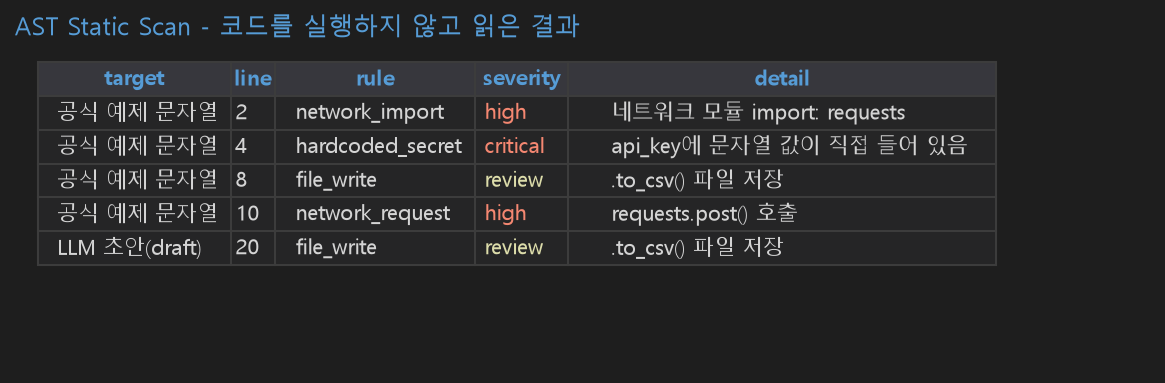

In [10]:
draft_scan = scan_generated_code(draft_code)
display(draft_scan)
print("내 LLM 초안 판정:", summarize_static_scan(draft_scan))

scan_view = pd.concat(
    [
        example_scan.assign(target="공식 예제 문자열"),
        draft_scan.assign(target="LLM 초안(draft)"),
    ],
    ignore_index=True,
)[["target", "line", "rule", "severity", "detail"]]

image_path = save_dataframe_image(
    scan_view,
    IMAGE_DIR / "step03_risk_scan.png",
    "AST Static Scan - 코드를 실행하지 않고 읽은 결과",
)
display(Image(filename=str(image_path)))

In [11]:
# 정적 스캔 0건이 "안전"이 아닌 이유 확인 (아래 문자열은 스캔만 하고 절대 실행하지 않습니다)
blind_spot_examples = {
    "단순 계산": "x = 1 + 1",
    "민감 파일 읽기": "secret_text = open('.env').read()",
    "개인 폴더 읽기": "import pandas as pd\ndf = pd.read_csv('C:/Users/someone/private/customers_raw.csv')",
}
rows = []
for label, snippet in blind_spot_examples.items():
    scan = scan_generated_code(snippet)
    rows.append({"예시": label, "findings": len(scan), "scan 판정": summarize_static_scan(scan)})
display(pd.DataFrame(rows))

,예시,findings,scan 판정
0,단순 계산,0,REVIEW
1,민감 파일 읽기,0,REVIEW
2,개인 폴더 읽기,0,REVIEW


### 실습 4 결과 확인 및 정리

### 결과 관찰
**공식 예제 문자열 (4건 → BLOCKED)**

| line | rule | severity |
| ---: | --- | --- |
| 2 | network_import (requests) | high |
| 4 | hardcoded_secret (API_KEY에 문자열 직접 입력) | critical |
| 8 | file_write (`.to_csv()`) | review |
| 10 | network_request (`requests.post()`) | high |

**내 LLM 초안**: 1건, `line 20 file_write (.to_csv())`, severity `review` → 판정 **REVIEW**.

**정적 스캔이 못 보는 것 확인** (스캔만 했고 실행은 하지 않았습니다)

| 예시 | findings | 판정 |
| --- | ---: | --- |
| 단순 계산 `x = 1 + 1` | 0 | REVIEW |
| `open('.env').read()` (민감 파일 읽기) | 0 | REVIEW |
| `pd.read_csv('C:/Users/someone/private/...')` (개인 폴더 읽기) | 0 | REVIEW |

스캔 결과 이미지는 `images/step03_risk_scan.png`에 저장했습니다.

### 나의 해석과 판단
- 공식 예제는 high/critical이 있어 `BLOCKED`입니다. 네트워크 전송, 파일 쓰기, 하드코딩 Key가 한 번에 들어 있어서 실행하면 안 되는 코드라는 게 코드를 실행하지 않고도 드러났습니다.
- **내 초안은 스캔으로는 거의 깨끗해 보입니다(1건, review).** 그런데 실습 1·3에서 봤듯이 분석은 71.6% 부풀려진 틀린 코드였습니다. 정적 스캔은 "위험한 호출이 있는가"만 보지 "분석이 맞는가"는 못 봅니다.
- 0건이어도 SAFE가 아닌 이유: `.env`나 개인 폴더를 **읽기만** 하는 코드는 이 스캔에서 0건으로 나옵니다. 그래서 0건이면 `SAFE`가 아니라 `REVIEW`로 두고 사람이 목적과 경로를 읽어야 합니다.

### 한계와 추가 확인 사항
이 스캐너는 제가 가이드의 대표 탐지 대상 목록에 맞춰 만든 단순한 규칙입니다. 문자열을 조합해서 숨기는 코드 등은 잡지 못할 수 있습니다.

## 실습 5. 회귀와 분류의 Feature Contract를 따로 검토하기

### AI에게 질문

> 같은 컬럼인데 어떤 문제에서는 쓰면 안 되고 어떤 문제에서는 써도 된다고 하는 이유가 뭔가요? 생성 코드가 ML 코드라면 이걸 어떻게 검증하나요?

### 초보자 상세 설명

Chapter09(회귀)에서는 `item_count`, `total_quantity` 같은 주문 상세 집계를 **금지**했고, Chapter10(분류)에서는 같은 컬럼을 **REVIEW 대상**으로 두고 썼습니다. 컬럼 이름이 문제가 아니라 **"무엇을 예측하느냐"와 "예측하는 시점에 이미 알 수 있느냐"** 가 문제이기 때문입니다.

- 회귀(order_total 예측): 금액·수량·단가·집계는 정답을 거의 그대로 알려 주는 값이라 금지
- 분류(취소 여부 예측): 장바구니 집계는 주문 생성 순간에 이미 확정되므로 REVIEW (단, 그 가정이 맞는지 사람이 확인)

아래에서 Feature Contract 표를 확인하고, 가이드 예시 목록과 **내가 Chapter09·10에서 실제로 쓴 feature 목록**을 같은 검증 함수로 다시 점검해 봅니다.

In [12]:
from src.llm_code_validation import build_feature_audit, build_leakage_review_table, validate_feature_list

leakage_contract = build_leakage_review_table()
display(leakage_contract.groupby(["problem", "status"]).size().unstack(fill_value=0))
display(leakage_contract)

status,ALLOWED,FORBIDDEN,REVIEW
problem,,,
classification,6,10,6
regression,6,11,0


,problem,feature,status,reason
0,regression,order_total,FORBIDDEN,예측 대상 자체
1,regression,line_total,FORBIDDEN,금액 정보가 곧 정답(order_total의 재료)
2,regression,quantity,FORBIDDEN,금액 계산의 재료라 정답을 간접 노출
3,regression,unit_price,FORBIDDEN,금액 계산의 재료라 정답을 간접 노출
4,regression,item_count,FORBIDDEN,주문 상세에서 만든 집계라 금액과 직접 연결
5,regression,total_quantity,FORBIDDEN,주문 상세에서 만든 집계라 금액과 직접 연결
6,regression,avg_unit_price,FORBIDDEN,금액에서 파생된 값
7,regression,order_status,FORBIDDEN,주문 이후에 확정되는 상태
8,regression,order_id,FORBIDDEN,식별자
9,regression,customer_id,FORBIDDEN,식별자


In [13]:
# 가이드 예시 목록
regression_features = ["payment_method", "order_month", "order_dayofweek", "gender", "age", "city"]
classification_features = ["payment_method", "item_count", "total_quantity", "order_amount", "age", "city"]

print("회귀 예시 통과:", validate_feature_list(regression_features, problem="regression"))
display(build_feature_audit(regression_features, problem="regression"))

print("분류 예시 통과:", validate_feature_list(classification_features, problem="classification"))
display(build_feature_audit(classification_features, problem="classification"))

회귀 예시 통과: True


,feature,status,reason
0,payment_method,ALLOWED,주문 시점에 확정
1,order_month,ALLOWED,주문 시점에 확정
2,order_dayofweek,ALLOWED,주문 시점에 확정
3,gender,ALLOWED,고객 비식별 특성
4,age,ALLOWED,고객 비식별 특성
5,city,ALLOWED,고객 비식별 특성


분류 예시 통과: True


,feature,status,reason
0,payment_method,ALLOWED,주문 시점에 확정
1,item_count,REVIEW,주문 생성 시 이미 확정된다는 가정이 맞는지 확인 필요
2,total_quantity,REVIEW,주문 생성 시 이미 확정된다는 가정이 맞는지 확인 필요
3,order_amount,REVIEW,주문 생성 시 이미 확정된다는 가정이 맞는지 확인 필요
4,age,ALLOWED,고객 비식별 특성
5,city,ALLOWED,고객 비식별 특성


In [14]:
# 같은 컬럼이 문제에 따라 다르게 판정되는지 + 금지 feature가 실제로 막히는지
for problem, features in [
    ("regression", ["payment_method", "order_total"]),
    ("regression", ["payment_method", "item_count"]),
    ("classification", ["payment_method", "order_status"]),
]:
    try:
        validate_feature_list(features, problem=problem)
        print(f"[{problem}] {features} -> 통과")
    except ValueError as error:
        print(f"[{problem}] {features} -> 차단: {error}")

print()
display(build_feature_audit(["item_count"], problem="regression").assign(problem="regression"))
display(build_feature_audit(["item_count"], problem="classification").assign(problem="classification"))

[regression] ['payment_method', 'order_total'] -> 차단: regression 문제에서 금지된 feature가 있습니다: ['order_total']
[regression] ['payment_method', 'item_count'] -> 차단: regression 문제에서 금지된 feature가 있습니다: ['item_count']
[classification] ['payment_method', 'order_status'] -> 차단: classification 문제에서 금지된 feature가 있습니다: ['order_status']



,feature,status,reason,problem
0,item_count,FORBIDDEN,주문 상세에서 만든 집계라 금액과 직접 연결,regression


,feature,status,reason,problem
0,item_count,REVIEW,주문 생성 시 이미 확정된다는 가정이 맞는지 확인 필요,classification


In [15]:
# 내가 Chapter09 / Chapter10에서 실제로 쓴 feature 목록을 같은 계약으로 다시 점검
# src.regression / src.classification을 import하면 scikit-learn(DLL)이 필요하지만, 이번 장은 코드를 "읽기만" 하는 장이라
# ast로 두 파일의 feature 상수만 읽어옵니다 (모듈을 실행하지 않음).
from src.llm_code_validation import read_feature_columns_from_source

CH09_FEATURES = read_feature_columns_from_source(PROJECT_ROOT / "src" / "regression.py")
CH10_FEATURES = read_feature_columns_from_source(PROJECT_ROOT / "src" / "classification.py")

print("Chapter09 회귀 features:", CH09_FEATURES)
print("통과:", validate_feature_list(CH09_FEATURES, problem="regression"))
display(build_feature_audit(CH09_FEATURES, problem="regression"))

print("\nChapter10 분류 features:", CH10_FEATURES)
print("통과:", validate_feature_list(CH10_FEATURES, problem="classification"))
display(build_feature_audit(CH10_FEATURES, problem="classification"))

Chapter09 회귀 features: ['order_month', 'order_dayofweek', 'age', 'payment_method', 'gender', 'city']
통과: True


,feature,status,reason
0,order_month,ALLOWED,주문 시점에 확정
1,order_dayofweek,ALLOWED,주문 시점에 확정
2,age,ALLOWED,고객 비식별 특성
3,payment_method,ALLOWED,주문 시점에 확정
4,gender,ALLOWED,고객 비식별 특성
5,city,ALLOWED,고객 비식별 특성



Chapter10 분류 features: ['order_month', 'order_dayofweek', 'age', 'item_count', 'total_quantity', 'order_amount', 'category_count', 'customer_tenure_days', 'payment_method', 'gender', 'city', 'dominant_category']
통과: True


,feature,status,reason
0,order_month,ALLOWED,주문 시점에 확정
1,order_dayofweek,ALLOWED,주문 시점에 확정
2,age,ALLOWED,고객 비식별 특성
3,item_count,REVIEW,주문 생성 시 이미 확정된다는 가정이 맞는지 확인 필요
4,total_quantity,REVIEW,주문 생성 시 이미 확정된다는 가정이 맞는지 확인 필요
5,order_amount,REVIEW,주문 생성 시 이미 확정된다는 가정이 맞는지 확인 필요
6,category_count,REVIEW,"장바구니 집계, 예측 시점에 확정된다는 가정 확인 필요"
7,customer_tenure_days,REVIEW,가입일이 주문일보다 늦은 행이 있어 그대로 쓰면 미래 정보 누수 가능
8,payment_method,ALLOWED,주문 시점에 확정
9,gender,ALLOWED,고객 비식별 특성


### 실습 5 결과 확인 및 정리

### 결과 관찰
**Feature Contract 요약**

| problem | ALLOWED | FORBIDDEN | REVIEW |
| --- | ---: | ---: | ---: |
| regression | 6 | 11 | 0 |
| classification | 6 | 10 | 6 |

- 가이드 예시 목록은 둘 다 통과했습니다. 회귀 예시는 6개 모두 ALLOWED, 분류 예시는 `item_count`, `total_quantity`, `order_amount` 3개가 REVIEW, 나머지는 ALLOWED였습니다.
- **같은 `item_count`가 회귀에서는 FORBIDDEN, 분류에서는 REVIEW**로 다르게 판정되었습니다.
- 금지 feature를 넣어 본 3가지(`order_total`, 회귀의 `item_count`, 분류의 `order_status`)는 모두 `ValueError`로 차단되었습니다.
- 내가 Chapter09에서 쓴 회귀 feature 6개(`order_month`, `order_dayofweek`, `age`, `payment_method`, `gender`, `city`)는 모두 ALLOWED였습니다.
- 내가 Chapter10에서 쓴 분류 feature 12개 중 6개(`order_month`, `order_dayofweek`, `age`, `payment_method`, `gender`, `city`)는 ALLOWED, 6개(`item_count`, `total_quantity`, `order_amount`, `category_count`, `dominant_category`, `customer_tenure_days`)는 REVIEW였습니다. FORBIDDEN은 0개였습니다.

### 나의 해석과 판단
Feature Leakage는 컬럼 **이름**의 문제가 아니라 **"무엇을 예측하는가"와 "예측하는 시점에 이미 알 수 있는가(Prediction Time)"** 의 문제입니다. `item_count`는 금액을 예측할 때는 정답을 거의 그대로 알려 주지만, 취소 여부를 예측할 때는 주문 생성 순간 이미 확정된 정보라 쓸 수 있습니다.

`customer_tenure_days`가 REVIEW인 것이 특히 의미 있었습니다. Chapter10에서 이 feature를 만들다가, 전체 300개 주문 중 56건(약 18.7%)에서 **가입일이 주문일보다 늦다**는 것을 발견하고 그 경우는 값을 만들지 않고 결측으로 처리했었습니다. 이름만 보면 문제없어 보이는 feature도 Prediction Time을 따져 보면 누수가 될 수 있다는 실제 사례입니다. REVIEW는 "금지"가 아니라 "사람이 예측 시점 가정을 확인해야 한다"는 뜻이라고 이해했습니다.

### 한계와 추가 확인 사항
`category_count`, `dominant_category`, `customer_tenure_days` 세 개는 가이드의 분류 계약 목록에는 없는, 제가 Chapter10에서 추가한 feature라서 이번에 제가 REVIEW로 직접 추가해서 점검했습니다. REVIEW 6개가 모두 "예측 시점에 확정된다"는 가정이 맞는지는 실제 서비스 흐름을 확인해야 최종 확정할 수 있습니다.

## 실습 6. Sandbox와 Package 검토하기

### AI에게 질문

> 코드를 승인해도 바로 내 컴퓨터에서 돌리면 안 된다고 하는데, 어떤 조건의 환경에서 돌려야 하나요? 그리고 LLM이 새 package를 설치하라고 하면 어떻게 판단하나요?

### 초보자 상세 설명

가이드의 Sandbox 조건(복사한 소량 샘플, read-only 입력, Secret 없음, 쓰기 경로 allowlist, network 차단, 시간·자원 제한, 실행 전 baseline 기록, 실행 후 변경 비교)과 새 package 설치 10가지 질문을 표로 불러왔습니다.

중요한 규칙은 **"자동 checklist의 REVIEW를 내가 임의로 PASS로 바꾸지 않는다"** 입니다. 지금은 아직 아무것도 확인하지 않았으니 전부 REVIEW가 맞고, 실제 Evidence를 확인한 뒤에만 바꿀 수 있습니다. Package는 초기 결정이 `DO_NOT_INSTALL_UNTIL_REVIEWED`입니다.

In [16]:
from src.llm_code_validation_policy import build_package_install_review, build_sandbox_execution_checklist

sandbox_checklist = build_sandbox_execution_checklist()
package_review = build_package_install_review()
display(sandbox_checklist)
display(package_review)

,item,what_to_check,status
0,복사한 소량 샘플만 사용,운영 데이터가 아니라 복사본인지 확인,REVIEW
1,input read-only 적용,입력 파일이 읽기 전용으로 바뀌었는지 확인,REVIEW
2,API Key / DB password / cloud credential 없음,실행 환경 변수에 Secret이 없는지 확인,REVIEW
3,disposable environment,실행 후 지워도 되는 폴더인지 확인,REVIEW
4,쓰기 경로 allowlist,output 폴더 밖에 쓰기가 없는지 확인,REVIEW
5,network deny by default,"네트워크 호출 코드가 없는지, OS 수준 차단이 되는지 확인",REVIEW
6,CPU / memory / timeout / process / disk limit,어떤 제한을 실제로 걸었는지 확인,REVIEW
7,실행 전 baseline 기록,실행 전 파일 목록/hash/크기 저장,REVIEW
8,실행 후 변경 비교,실행 후 생성/수정/삭제 파일 비교,REVIEW


,question,status,initial_decision
0,정말 필요한가?,REVIEW,DO_NOT_INSTALL_UNTIL_REVIEWED
1,공식 package 이름과 source인가?,REVIEW,DO_NOT_INSTALL_UNTIL_REVIEWED
2,typosquatting 위험은 없는가?,REVIEW,DO_NOT_INSTALL_UNTIL_REVIEWED
3,exact version을 고정했는가?,REVIEW,DO_NOT_INSTALL_UNTIL_REVIEWED
4,Python 호환성을 확인했는가?,REVIEW,DO_NOT_INSTALL_UNTIL_REVIEWED
5,transitive dependency를 검토했는가?,REVIEW,DO_NOT_INSTALL_UNTIL_REVIEWED
6,install script를 검토했는가?,REVIEW,DO_NOT_INSTALL_UNTIL_REVIEWED
7,격리 환경인가?,REVIEW,DO_NOT_INSTALL_UNTIL_REVIEWED
8,requirements / lock에 기록하는가?,REVIEW,DO_NOT_INSTALL_UNTIL_REVIEWED
9,조직 정책에 맞는가?,REVIEW,DO_NOT_INSTALL_UNTIL_REVIEWED


### 실습 6 결과 확인 및 정리

### 결과 관찰
- Sandbox 체크리스트 9개 항목은 **전부 `REVIEW`** 입니다. (복사한 샘플 / read-only / Secret 없음 / disposable / 쓰기 경로 allowlist / network deny / 자원 제한 / 실행 전 baseline / 실행 후 변경 비교)
- Package 설치 검토 10개 질문도 전부 `REVIEW`, 초기 결정은 모두 `DO_NOT_INSTALL_UNTIL_REVIEWED`였습니다.

### 나의 해석과 판단
아직 아무 Evidence도 확인하지 않았으니 전부 REVIEW인 것이 맞습니다. 이 표를 내가 마음대로 PASS로 바꾸지 않고, 실습 9에서 실제로 확인한 항목만 근거와 함께 따져 보겠습니다. 이번 코드는 `pandas` 하나만 쓰고 새 package 설치를 요구하지 않아서, package 결정은 **`DO_NOT_INSTALL_UNTIL_REVIEWED`를 그대로 유지**합니다.

## 실습 7. 전체 Evidence와 Execution Gate 확인하기

### AI에게 질문

> 지금까지 확인한 것들을 한 번에 모아서 "이 코드를 실행해도 되는지"를 보여주는 표가 있나요? 결과가 DO_NOT_EXECUTE로 나오면 자동화가 실패한 건가요?

### 초보자 상세 설명

`run_llm_code_validation`은 위 검증들을 한 번에 돌려서 Execution Gate 표를 만들고 `reports/ch12_*.csv`로 저장합니다. 이 함수도 정적 스캔 대상 코드를 **실행하지 않고** AST로만 읽습니다.

Gate의 축은 `schema_and_keys / aggregate_validation / ml_leakage / static_scan / sandbox_and_package / human_approval / execution_decision`입니다. 판정 원칙은 다음과 같습니다.

- FAIL 또는 BLOCKED가 하나라도 있으면 → `DO_NOT_EXECUTE`
- 자동으로 차단할 항목이 없으면 → `HUMAN_REVIEW_REQUIRED` (자동으로 EXECUTE가 되는 경우는 없음)

`DO_NOT_EXECUTE`는 "자동화가 고장났다"가 아니라 **"지금 검사한 코드에 차단 사유가 있다"** 는 뜻입니다. 먼저 공식 예제 문자열로 Gate를 만들고, 그다음 내 LLM 초안으로도 만들어서 비교해 봅니다.

In [17]:
from src.llm_code_validation_policy import run_llm_code_validation

official_result = run_llm_code_validation(processed_dir=PROCESSED_DIR, report_dir=REPORT_DIR)
display(official_result["outputs"]["execution_gate"])
print("공식 예제 최종 결정:", official_result["decision"])

,axis,status,evidence
0,schema_and_keys,PASS,필수 컬럼/PK/FK 검증 통과
1,aggregate_validation,PASS,source total = category total = monthly total
2,ml_leakage,REVIEW,FORBIDDEN 0건 / REVIEW 3건
3,static_scan,BLOCKED,DEFAULT_STATIC_SCAN_EXAMPLE: findings 4건
4,sandbox_and_package,REVIEW,체크리스트 전 항목 REVIEW (자동으로 PASS 만들지 않음)
5,human_approval,PENDING,사람 승인 전
6,execution_decision,DO_NOT_EXECUTE,


공식 예제 최종 결정: DO_NOT_EXECUTE


In [18]:
# 내 LLM 초안(draft)으로 Gate 만들기 (ml_leakage 축은 내 Chapter09/10 feature 목록 기준)
my_feature_lists = {"regression": CH09_FEATURES, "classification": CH10_FEATURES}

draft_result = run_llm_code_validation(
    processed_dir=PROCESSED_DIR,
    report_dir=STUDENT_REPORT_DIR / "draft",
    generated_code=draft_code,
    code_label="draft_category_sales.py",
    feature_lists=my_feature_lists,
)
display(draft_result["outputs"]["execution_gate"])
print("초안 최종 결정:", draft_result["decision"])

,axis,status,evidence
0,schema_and_keys,PASS,필수 컬럼/PK/FK 검증 통과
1,aggregate_validation,PASS,source total = category total = monthly total
2,ml_leakage,REVIEW,FORBIDDEN 0건 / REVIEW 6건
3,static_scan,REVIEW,draft_category_sales.py: findings 1건
4,sandbox_and_package,REVIEW,체크리스트 전 항목 REVIEW (자동으로 PASS 만들지 않음)
5,human_approval,PENDING,사람 승인 전
6,execution_decision,HUMAN_REVIEW_REQUIRED,


초안 최종 결정: HUMAN_REVIEW_REQUIRED


### 실습 7 결과 확인 및 정리

### 결과 관찰
**공식 예제 문자열의 Execution Gate**

| axis | status |
| --- | --- |
| schema_and_keys | PASS |
| aggregate_validation | PASS |
| ml_leakage | REVIEW (FORBIDDEN 0건 / REVIEW 3건) |
| static_scan | **BLOCKED** (findings 4건) |
| sandbox_and_package | REVIEW |
| human_approval | PENDING |
| execution_decision | **DO_NOT_EXECUTE** |

**내 LLM 초안의 Execution Gate**는 `static_scan`이 REVIEW(findings 1건), `ml_leakage`가 REVIEW(내 Chapter09/10 feature 기준 REVIEW 6건)여서 `execution_decision`이 **`HUMAN_REVIEW_REQUIRED`** 였습니다.

### 나의 해석과 판단
- 공식 예제가 `DO_NOT_EXECUTE`로 나온 것은 정상입니다. 자동화가 실패한 게 아니라 "지금 검사한 코드에 차단 사유(BLOCKED)가 있다"는 뜻입니다.
- 오히려 조심해야 하는 쪽은 **내 초안**입니다. Gate가 막지 않았다(`HUMAN_REVIEW_REQUIRED`)고 해서 이 코드가 맞다는 뜻이 아닙니다. 실습 3에서 확인했듯이 이 코드는 completed 범위를 지키지 못해 매출이 71.6% 부풀려지는 틀린 분석입니다. Gate의 `aggregate_validation`은 **검증 함수(`safe_category_sales`)** 가 PASS라는 뜻이지 **내 초안 코드가 PASS**라는 뜻이 아닙니다. 자동 검증 PASS는 실행 승인이 아닙니다.
- 이 Gate는 어떤 경우에도 자동으로 `EXECUTE`를 만들지 않습니다. 승인은 사람이 따로 해야 합니다.
- `ml_leakage` 축은 이 코드가 ML 코드가 아니라서 의미가 약하지만, 내 Chapter09/10 feature 목록으로 같은 Gate에 넣어 REVIEW 6건이 그대로 표시되는지만 확인했습니다.

### Evidence
`execution_gate` 표, `reports/ch12_execution_gate.csv`(공식 예제), `reports/ch12_student/draft/`(내 초안), 스크립트 재실행 결과(실습 12)와 Notebook Gate가 일치한 것.

## 실습 8. 사람의 APPROVE / REVISE / BLOCK 판단과 수정

### AI에게 질문

> 자동 검증에서 차단이 안 된 초안은 그냥 승인해도 되나요? 판단 근거는 어떻게 적어야 하나요?

### 초보자 상세 설명

가이드는 판단 근거에 **분석 타당성 + 실행 안전** 두 축을 모두 넣으라고 했습니다.

- APPROVE: 검토한 코드가 제한 실행 후보가 됨
- REVISE: 문제를 수정한 뒤 다시 검토해야 함
- BLOCK: 현재 상태에서는 실행하지 않음

바로 앞 실습 7에서 초안의 Gate가 `HUMAN_REVIEW_REQUIRED`였던 것이 오히려 함정입니다. 자동 검증이 막지 않았다고 분석이 맞는 건 아니기 때문에, 실습 1~3에서 읽고 확인한 근거로 **사람이 직접** 판단합니다.

수정한 코드는 `generated_code/revised_category_sales.py`에 저장했습니다. 수정 내용을 사람 수정 Log로 남기고, 수정본도 같은 스캔과 Gate를 다시 통과시킵니다.

In [19]:
revised_path = GENERATED_DIR / "revised_category_sales.py"
revised_code = revised_path.read_text(encoding="utf-8")

for line_no, line in enumerate(revised_code.splitlines(), start=1):
    print(f"{line_no:2d} | {line}")

 1 | import pandas as pd
 2 | 
 3 | orders = pd.read_csv("data/processed/orders_clean.csv")
 4 | items = pd.read_csv("data/processed/order_items_clean.csv")
 5 | products = pd.read_csv("data/processed/products_clean.csv")
 6 | 
 7 | assert orders["order_id"].is_unique
 8 | assert products["product_id"].is_unique
 9 | assert (items["line_total"] == items["quantity"] * items["unit_price"]).all()
10 | 
11 | completed_orders = orders.loc[orders["order_status"] == "completed", ["order_id"]]
12 | completed_items = items.merge(
13 |     completed_orders, on="order_id", how="inner", validate="many_to_one"
14 | )
15 | 
16 | merged = completed_items.merge(
17 |     products[["product_id", "category"]],
18 |     on="product_id",
19 |     how="left",
20 |     validate="many_to_one",
21 |     indicator=True,
22 | )
23 | assert (merged["_merge"] == "both").all()
24 | assert merged["category"].notna().all()
25 | 
26 | result = (
27 |     merged.groupby("category", as_index=False)["line_total"]
28 |  

In [20]:
revised_scan = scan_generated_code(revised_code)
display(revised_scan)
print("수정본 스캔 판정:", summarize_static_scan(revised_scan), f"(findings {len(revised_scan)}건)")

revised_result = run_llm_code_validation(
    processed_dir=PROCESSED_DIR,
    report_dir=STUDENT_REPORT_DIR / "revised",
    generated_code=revised_code,
    code_label="revised_category_sales.py",
    feature_lists=my_feature_lists,
)
display(revised_result["outputs"]["execution_gate"])
print("수정본 자동 결정:", revised_result["decision"], "(EXECUTE가 아님 - 사람 승인이 따로 필요)")

,line,rule,severity,detail
0,35,file_write,review,.to_csv() 파일 저장


수정본 스캔 판정: REVIEW (findings 1건)


,axis,status,evidence
0,schema_and_keys,PASS,필수 컬럼/PK/FK 검증 통과
1,aggregate_validation,PASS,source total = category total = monthly total
2,ml_leakage,REVIEW,FORBIDDEN 0건 / REVIEW 6건
3,static_scan,REVIEW,revised_category_sales.py: findings 1건
4,sandbox_and_package,REVIEW,체크리스트 전 항목 REVIEW (자동으로 PASS 만들지 않음)
5,human_approval,PENDING,사람 승인 전
6,execution_decision,HUMAN_REVIEW_REQUIRED,


수정본 자동 결정: HUMAN_REVIEW_REQUIRED (EXECUTE가 아님 - 사람 승인이 따로 필요)


In [21]:
from src.llm_code_validation_policy import build_human_revision_log

revision_entries = [
    {
        "item": "주문 상태 범위",
        "llm_draft": "상태 필터 없이 모든 주문 상세를 합산",
        "human_revision": "orders에서 completed만 남겨 inner merge (validate='many_to_one')",
        "reason": f"모든 상태 합계 {all_status_total:,} vs completed {source_total:,} - 취소/환불 주문이 매출에 섞임",
    },
    {
        "item": "merge 검증",
        "llm_draft": "how='left' merge, validate/indicator 없음",
        "human_revision": "validate='many_to_one' + indicator=True + assert 'both'/category 결측 없음",
        "reason": "key가 중복되거나 매칭이 안 되어도 에러 없이 행/금액이 달라질 수 있음",
    },
    {
        "item": "금액 계산식",
        "llm_draft": "quantity * products.price",
        "human_revision": "order_items.line_total 사용 + line_total == quantity*unit_price assert",
        "reason": f"지금은 price/unit_price 불일치 {price_mismatch}건이지만, 상품 가격이 바뀌면 과거 주문 금액이 틀려짐",
    },
    {
        "item": "입력 가정 검증",
        "llm_draft": "orders/products key 고유성 확인 없음",
        "human_revision": "orders.order_id, products.product_id 고유성 assert 추가",
        "reason": "고유하지 않으면 many_to_one 가정이 깨져 금액이 중복 집계됨",
    },
    {
        "item": "출력 경로",
        "llm_draft": "C:/reports/category_sales.csv (절대 경로, 기존 파일 덮어쓰기 가능)",
        "human_revision": "output/category_sales.csv (승인된 output 폴더 안의 상대 경로)",
        "reason": "허용 경로 밖 쓰기를 막고 실행 전후 변경 비교를 가능하게 함",
    },
]

decision_table = pd.DataFrame(
    [
        {"대상": "draft_category_sales.py", "판단": "REVISE", "분석 타당성": "FAIL (completed 범위, merge 검증 부족)", "실행 안전": "REVIEW (절대 경로 쓰기)"},
        {"대상": "revised_category_sales.py", "판단": "APPROVE (제한 실행 후보)", "분석 타당성": "PASS (실습 2~3 기준)", "실행 안전": "REVIEW (상대 경로 쓰기 1건, 제한 환경에서만)"},
    ]
)
display(decision_table)

# 사람이 REVISE -> 재검토 -> APPROVE를 마친 뒤에만 execution_approved를 True로 기록
human_revision_log = build_human_revision_log(revision_entries, execution_approved=True)
display(human_revision_log)
STUDENT_REPORT_DIR.mkdir(parents=True, exist_ok=True)
human_revision_log.to_csv(STUDENT_REPORT_DIR / "ch12_human_revision_log.csv", index=False, encoding="utf-8-sig")

,대상,판단,분석 타당성,실행 안전
0,draft_category_sales.py,REVISE,"FAIL (completed 범위, merge 검증 부족)",REVIEW (절대 경로 쓰기)
1,revised_category_sales.py,APPROVE (제한 실행 후보),PASS (실습 2~3 기준),"REVIEW (상대 경로 쓰기 1건, 제한 환경에서만)"


,item,llm_draft,human_revision,reason,execution_approved
0,주문 상태 범위,상태 필터 없이 모든 주문 상세를 합산,orders에서 completed만 남겨 inner merge (validate='...,"모든 상태 합계 255,610,000 vs completed 148,990,000 ...",True
1,merge 검증,"how='left' merge, validate/indicator 없음",validate='many_to_one' + indicator=True + asse...,key가 중복되거나 매칭이 안 되어도 에러 없이 행/금액이 달라질 수 있음,True
2,금액 계산식,quantity * products.price,order_items.line_total 사용 + line_total == quan...,"지금은 price/unit_price 불일치 0건이지만, 상품 가격이 바뀌면 과거 ...",True
3,입력 가정 검증,orders/products key 고유성 확인 없음,"orders.order_id, products.product_id 고유성 asser...",고유하지 않으면 many_to_one 가정이 깨져 금액이 중복 집계됨,True
4,출력 경로,"C:/reports/category_sales.csv (절대 경로, 기존 파일 덮어...",output/category_sales.csv (승인된 output 폴더 안의 상대...,허용 경로 밖 쓰기를 막고 실행 전후 변경 비교를 가능하게 함,True


### 실습 8 결과 확인 및 정리

## 사람의 판단

| 대상 | 판단 | 분석 타당성 | 실행 안전 |
| --- | --- | --- | --- |
| `draft_category_sales.py` | **REVISE** | FAIL (completed 범위, merge 검증 부족) | REVIEW (절대 경로 쓰기) |
| `revised_category_sales.py` | **APPROVE (제한 실행 후보)** | PASS (실습 2~3 기준) | REVIEW (상대 경로 쓰기 1건, 제한 환경에서만) |

### 판단 근거
- 초안을 REVISE로 본 이유 1(분석): 상태 필터가 없어 completed 대신 모든 상태를 합산했고(255,610,000 vs 148,990,000), merge 검증이 없습니다.
- 이유 2(실행 안전): `C:/reports/category_sales.csv`라는 고정된 절대 경로에 저장해서 기존 파일을 덮어쓸 수 있습니다. (네트워크, Shell, Secret 문제는 없었습니다.)
- 수정본을 APPROVE로 본 이유: 분석 쪽은 completed 범위 / merge validate / 행 수 / 총합 대조를 모두 통과했고, 안전 쪽은 정적 스캔 findings가 1건(`output/category_sales.csv` 저장, review)뿐이며 이는 승인된 output 폴더 안의 상대 경로입니다. 그래도 실행 안전은 REVIEW라서 **제한 환경에서만** 실행합니다.

## 사람 수정 내용 (LLM 초안 → 내 수정)

| 항목 | LLM 초안 | 내 수정 |
| --- | --- | --- |
| 주문 상태 범위 | 상태 필터 없이 모든 주문 상세 합산 | completed만 남겨 inner merge (`validate="many_to_one"`) |
| merge 검증 | `how="left"`, validate/indicator 없음 | `validate="many_to_one"` + `indicator=True` + `assert` |
| 금액 계산식 | `quantity * products.price` | `line_total` 사용 + `line_total == quantity*unit_price` assert |
| 입력 가정 검증 | key 고유성 확인 없음 | `orders.order_id`, `products.product_id` 고유성 assert |
| 출력 경로 | `C:/reports/category_sales.csv` (절대 경로, 덮어쓰기 가능) | `output/category_sales.csv` (승인된 폴더 안 상대 경로) |

수정본을 다시 정적 스캔한 결과는 1건(`line 35 file_write`, review) → **REVIEW**, Gate는 `HUMAN_REVIEW_REQUIRED`였습니다. 사람 수정 Log에는 REVISE → 재검토 → APPROVE까지 끝난 뒤에 `execution_approved = True`로 기록했고, 파일은 `reports/ch12_student/ch12_human_revision_log.csv`에 저장했습니다.

### 한계와 추가 확인 사항
이 승인은 **학생인 제가 혼자** 한 것입니다. 실제 업무라면 코드를 작성하거나 요청한 사람과 다른 사람이 한 번 더 검토하는 단계가 필요합니다.

## 실습 9. 승인된 코드만 제한 환경에서 실행하기

### AI에게 질문

> APPROVE한 코드를 실제로 돌릴 때 "제한된 환경"을 Windows에서 어떻게 만들 수 있나요? 실행 전후에 무엇을 기록해야 하나요?

### 초보자 상세 설명

이 단계는 **앞에서 APPROVE한 수정본(`revised_category_sales.py`)에만** 적용합니다. 공식 예제 문자열이나 LLM 초안은 실행하지 않습니다.

제가 실제로 적용한 제한은 이렇습니다.

- 원본이 아닌 **복사본** 폴더(`_sandbox`)에서 실행, 폐기 가능
- 입력 CSV 4개를 **읽기 전용**으로 변경
- 실행 환경변수를 최소한만 전달해서 API Key·Token 같은 Secret이 안 들어가게 함
- 쓰기 허용 폴더는 `output/` 하나, 실행 전/후 파일 hash 비교
- timeout 60초

그리고 **적용하지 못한 제한**도 정직하게 적어 둡니다. 이번 실습에서는 OS 수준의 네트워크 차단과 CPU·메모리 상한은 걸지 못했습니다. 그래서 네트워크는 "정적 스캔에서 호출이 없었다"는 근거만 있고 확정은 못 합니다.

실행 결과 화면은 `images/step06_limited_run.png`로 저장합니다.

In [22]:
from src.llm_code_validation_policy import run_in_limited_sandbox

run_result = run_in_limited_sandbox(
    code_path=revised_path,
    processed_dir=PROCESSED_DIR,
    sandbox_dir=SANDBOX_DIR,
    timeout_sec=60,
)

display(run_result["run_info"])
print("[실행 중 출력 stdout]")
print(run_result["stdout"])
print("[stderr]", run_result["stderr"] or "(없음)")
print("[실행 전후 파일 변경]")
display(run_result["changes"])

,항목,값
0,실행 대상 코드,revised_category_sales.py
1,실행 대상 sha256,b4c2f041c77ca512
2,Python,3.14.7
3,pandas,3.0.5
4,sandbox 폴더,_sandbox
5,입력 파일 수 / read-only,4개 / 적용
6,환경변수 전달,"APPDATA, PATH, PYTHONDONTWRITEBYTECODE, PYTHON..."
7,Secret 이름 환경변수,없음
8,timeout 설정(초),60
9,시작 시각,2026-10-06 15:19:40


[실행 중 출력 stdout]
category    sales
     스포츠 31743000
    전자기기 26400000
    생활용품 23915000
      뷰티 23383000
      식품 16573000
      도서 16389000
      패션 10587000
행 수: 474 합계: 148990000

[stderr] (없음)
[실행 전후 파일 변경]


,path,change,inside_allowed_path
0,output/category_sales.csv,created,True


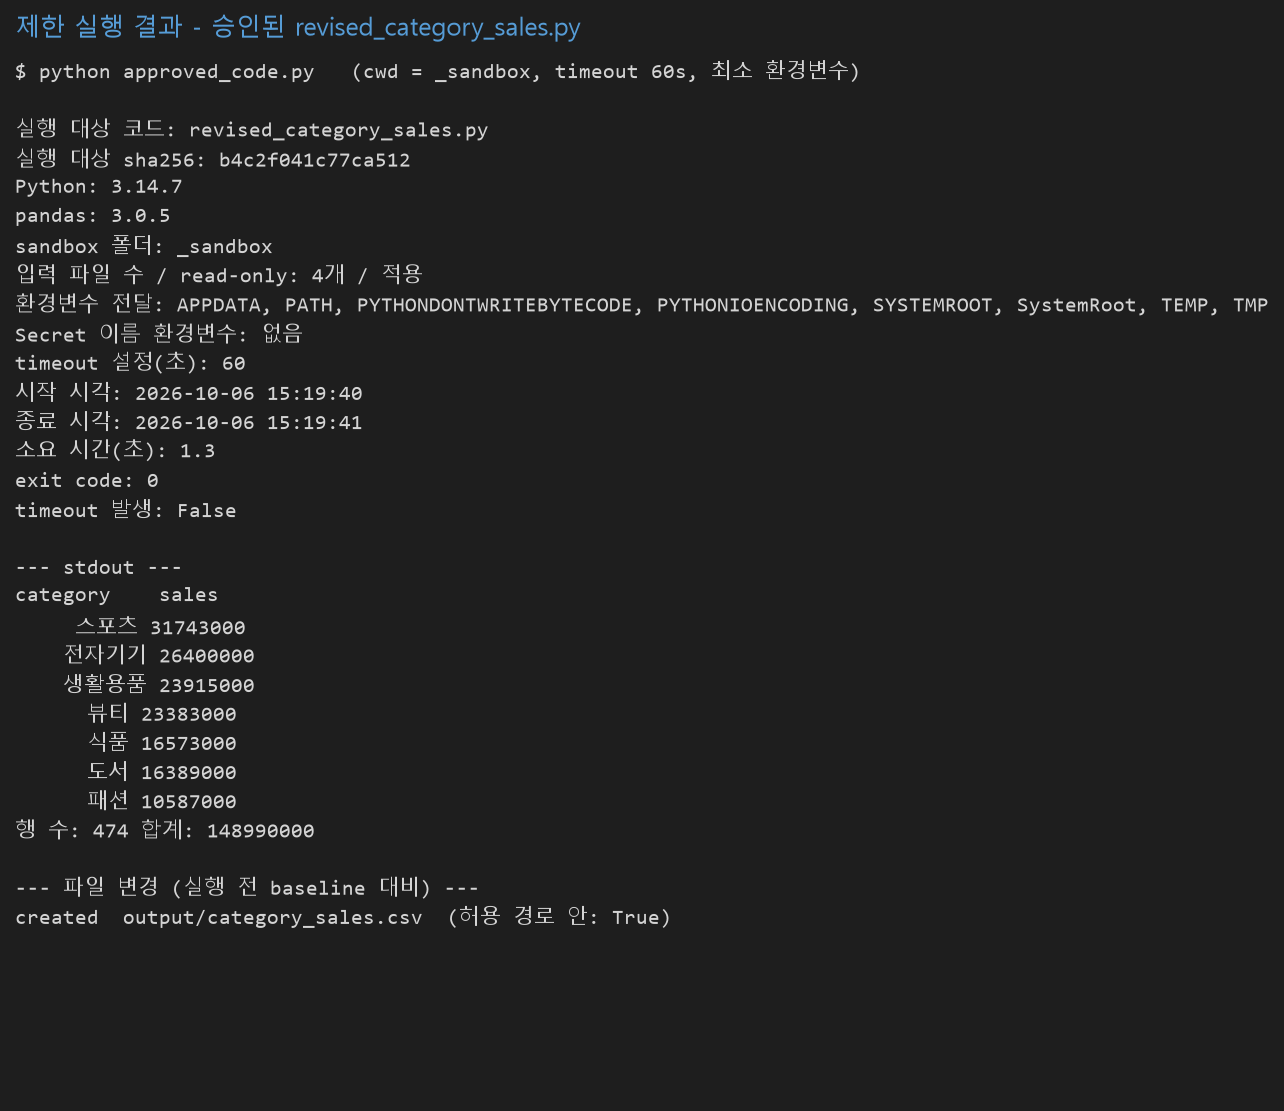

In [23]:
from src.llm_code_validation import save_text_image

log_lines = ["$ python approved_code.py   (cwd = _sandbox, timeout 60s, 최소 환경변수)", ""]
log_lines += [f"{row['항목']}: {row['값']}" for _, row in run_result["run_info"].iterrows()]
log_lines += ["", "--- stdout ---", *run_result["stdout"].rstrip().splitlines()]
log_lines += ["", "--- 파일 변경 (실행 전 baseline 대비) ---"]
log_lines += [
    f"{row['change']:8s} {row['path']}  (허용 경로 안: {row['inside_allowed_path']})"
    for _, row in run_result["changes"].iterrows()
]

image_path = save_text_image(
    "\n".join(log_lines),
    IMAGE_DIR / "step06_limited_run.png",
    "제한 실행 결과 - 승인된 revised_category_sales.py",
)
display(Image(filename=str(image_path)))

### 실습 9 결과 확인 및 정리

### 결과 관찰
- 실행 대상: **APPROVE한 `revised_category_sales.py`만** 실행했고, 공식 예제 문자열과 LLM 초안은 실행하지 않았습니다.
- exit code 0, timeout 없음, stderr 없음 (실행 시간은 약 1초).
- 화면 출력의 마지막 줄: `행 수: 474 합계: 148990000`, 카테고리별 금액은 실습 3의 검증 결과와 같은 순서·같은 값이었습니다.
- 실행 전후 파일 변경: `output/category_sales.csv` **created** 1건뿐, 허용 경로 안(True).
- 실제로 적용한 제한: 복사본 폴더 `_sandbox`, 입력 CSV 4개 read-only, 필요한 환경변수만 전달(Secret 이름 환경변수 없음), 쓰기 허용은 `output/` 하나, 실행 전/후 파일 hash 비교, timeout 60초.
- 실행 화면은 `images/step06_limited_run.png`로 저장했습니다.

### 나의 해석과 판단
Sandbox 체크리스트 중 실제 Evidence로 확인한 항목은 이렇습니다.

| 항목 | 이번 실습에서의 상태 |
| --- | --- |
| 복사한 샘플만 사용 | 확인함 (`_sandbox` 복사본) |
| input read-only | 적용함 |
| Secret 없음 | 전달한 환경변수 이름에 key/token/secret/password가 없음을 확인함 |
| 쓰기 경로 allowlist | 실행 전후 비교에서 `output/` 밖 변경 0건을 확인함 |
| 실행 전 baseline / 실행 후 변경 비교 | 파일 hash로 수행함 |
| timeout | 60초 적용함 |
| network deny | **적용하지 못함** (정적 스캔상 호출이 없었다는 근거만 있음) |
| CPU / memory 제한 | **적용하지 못함** |

### 한계와 추가 확인 사항
OS 수준의 네트워크 차단과 CPU·메모리 제한은 이번 환경에서 걸지 못했습니다. 그래서 "외부로 전송하지 않았다"는 점은 정적 스캔에 근거한 추정이고 확정이 아닙니다. 이 항목들은 계속 `REVIEW`로 남깁니다.

## 실습 10. 실행 성공 메시지보다 Post-execution Validation 확인하기

### AI에게 질문

> 코드가 에러 없이 끝났으면 결과를 믿어도 되나요? 실행 후에는 무엇을 다시 확인해야 하나요?

### 초보자 상세 설명

가이드의 한 줄은 이것이었습니다. **코드 실행 성공 ≠ 분석 결과 검증 완료.** 그래서 이번에는 수정본 코드가 끝난 뒤에, 수정본의 코드를 재사용하지 않고 **별도로 다시 계산한 값**과 출력 파일을 비교합니다.

확인하는 것: exit code, 예상한 파일 1개만 생성되었는가, 원본 입력 파일이 그대로인가, 출력 행 수, 출력 합계와 source total, 카테고리별 금액, 로그에 Secret 흔적이 없는가, 외부 네트워크 전송 여부.

결과는 `images/step07_post_validation.png`로 저장합니다.

,check,value,status,note
0,exit code 0 / timeout 없음,0 / False,PASS,
1,생성된 파일이 예상 출력 1개뿐인가,output/category_sales.csv,PASS,
2,수정/삭제된 파일 또는 허용 경로 밖 변경,0,PASS,0이어야 원본 입력이 보존됨
3,입력 파일 hash가 실행 전후 같은가,True,PASS,
4,입력 completed 주문 상세 행 수,474,INFO,
5,출력 행 수 (카테고리 수),7,PASS,독립 계산: 7개
6,출력 합계 = source completed total,148990000,PASS,source=148990000
7,카테고리별 금액이 독립 계산과 같은가,True,PASS,
8,category 결측 없음,0,PASS,
9,로그에 Secret 흔적이 없는가,없음,PASS,


,category,sales
0,스포츠,31743000
1,전자기기,26400000
2,생활용품,23915000
3,뷰티,23383000
4,식품,16573000
5,도서,16389000
6,패션,10587000


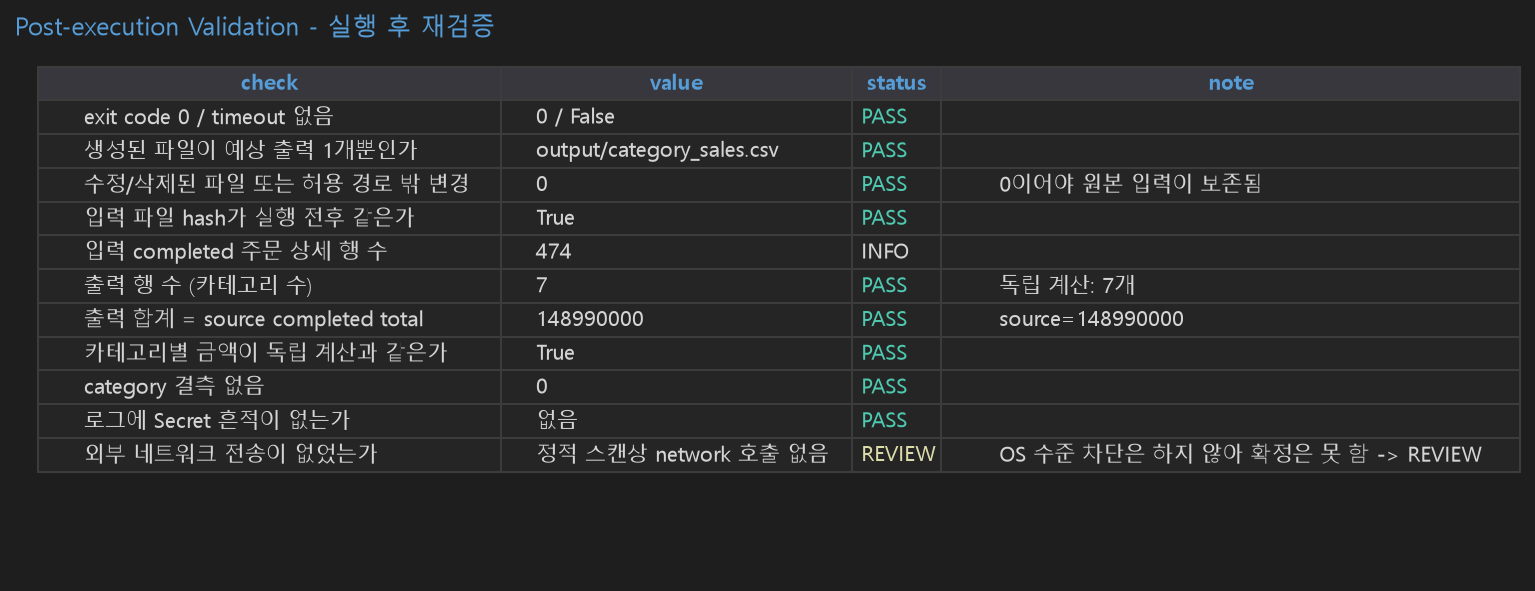

In [24]:
from src.llm_code_validation_policy import post_execution_validation

post_validation = post_execution_validation(run_result, datasets, output_name="category_sales.csv")
display(post_validation)

output_df = pd.read_csv(SANDBOX_DIR / "output" / "category_sales.csv")
display(output_df)

image_path = save_dataframe_image(
    post_validation[["check", "value", "status", "note"]],
    IMAGE_DIR / "step07_post_validation.png",
    "Post-execution Validation - 실행 후 재검증",
)
display(Image(filename=str(image_path)))

### 실습 10 결과 확인 및 정리

### 결과 관찰 (실행 후 검증 11개 항목)
- **PASS 9개**: exit code 0 / timeout 없음, 생성 파일이 예상 출력 1개뿐, 수정·삭제·허용 경로 밖 변경 0건, 입력 파일 hash 실행 전후 동일, 출력 행 수 7(독립 계산 7), 출력 합계 148,990,000 = source completed total, 카테고리별 금액이 독립 계산과 동일, category 결측 0, 로그에 Secret 흔적 없음.
- **INFO 1개**: 입력 completed 주문 상세 행 수 474.
- **REVIEW 1개**: "외부 네트워크 전송이 없었는가" - 정적 스캔상 호출이 없었다는 것뿐이라 확정하지 못함.
- 출력 파일 `output/category_sales.csv`는 7개 카테고리, 실습 3의 검증 결과와 같은 값이었습니다. 사후 검증 화면은 `images/step07_post_validation.png`에 저장했습니다.

### 나의 해석과 판단
코드가 에러 없이 끝나는 것(exit code 0)은 11개 중 하나일 뿐입니다. 이번에는 수정본 코드의 계산을 그대로 믿지 않고, **별도로 독립 계산한 값**(상태 필터 후 category별 합계)과 출력 파일을 비교했기 때문에 "분석 결과가 맞다"고 말할 수 있었습니다. 코드 실행 성공이 분석 결과 검증 완료와 같지 않다는 것을 이번에 직접 확인했습니다.

### 한계와 추가 확인 사항
네트워크 전송 여부는 REVIEW로 남았습니다. 또 "독립 계산"도 같은 입력 CSV를 같은 pandas로 다시 계산한 것이라, 입력 데이터 자체의 정확성(예: 실제 매출 시스템과의 일치)까지 확인한 것은 아닙니다.

## 실습 11. 오류를 LLM에게 다시 물을 때도 최소 Context만 공유하기

### AI에게 질문

> 코드가 에러가 났을 때 LLM에게 도움을 받으려면 전체 데이터와 로그를 붙여 넣어도 되나요?

### 초보자 상세 설명

안 됩니다. 고객 원본 행, API Key, Token, DB password, 내부 URL, 개인 사용자 경로, 전체 환경변수는 공유하지 않고, **분석 목적 / 필요한 최소 dataset·column 구조 / 오류를 재현하는 최소 코드 / 정리한 오류 메시지 / 행 수·미매칭·총합 차이 같은 Evidence**만 공유합니다. 아래는 공통 Prompt Template입니다.

In [25]:
from src.llm_code_validation import build_error_fix_prompt_template

print(build_error_fix_prompt_template())

# 오류 수정 요청 Prompt (최소 Context)

## 분석 목적
(한 문장)

## 필요한 최소 데이터 구조
- dataset 이름과 필요한 컬럼명만 적습니다. 고객 원본 행은 붙이지 않습니다.

## 오류를 재현하는 최소 코드
(문자열 literal / URL / 경로에 개인정보·Secret이 없는지 다시 확인)

## 오류 메시지
(사용자명, 절대 경로, 내부 URL, 토큰을 지운 뒤 붙입니다)

## 검증 Evidence
- merge 전후 행 수:
- 미매칭 수:
- source total과 grouped total 차이:

## 공유하지 않는 것
고객 원본 행, API Key, Token, DB password, 내부 URL, 개인 사용자 경로, 전체 환경변수, 민감 설정 파일



### 실습 11 결과 확인 및 정리

### 결과 관찰
공통 Prompt Template이 `분석 목적 / 필요한 최소 데이터 구조 / 오류를 재현하는 최소 코드 / 오류 메시지 / 검증 Evidence / 공유하지 않는 것` 6개 구역으로 출력되었습니다.

### 나의 해석과 판단
만약 이번 실습에서 에러가 나서 LLM에게 물어본다면, 저는 이렇게 하겠습니다.
- 붙인다: "completed 주문의 카테고리별 line_total 합계를 구하는 코드"라는 목적, 필요한 컬럼명(`order_id, order_status, product_id, category, line_total`), 오류를 재현하는 5~10줄, 그리고 merge 전후 행 수와 총합 차이 같은 숫자.
- 지운다: 고객 이름·원본 행, 내 컴퓨터의 사용자명이 들어간 절대 경로(`C:/Users/...`), 환경변수 전체, 로그에 찍힌 토큰 등.
- 최소 재현 코드 안의 문자열 literal과 URL에 개인정보나 내부 주소가 섞여 있지 않은지 한 번 더 확인합니다.

## 실습 12. Evidence 파일 저장과 전체 스크립트 재실행 확인하기

### AI에게 질문

> Notebook에서 만든 Evidence가 스크립트로 다시 돌려도 같은 결과로 나오는지, 그리고 파일이 실제로 생겼는지 어떻게 확인하나요?

In [26]:
import subprocess

script_run = subprocess.run(
    [sys.executable, str(PROJECT_ROOT / "scripts" / "run_llm_code_validation.py")],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    encoding="utf-8",
    env={**__import__("os").environ, "PYTHONIOENCODING": "utf-8"},
)
print("스크립트 exit code:", script_run.returncode)
print("\n".join(script_run.stdout.splitlines()[:12]))

files = [path for path in sorted(REPORT_DIR.glob("ch12_*")) if path.is_file()]
evidence_files = pd.DataFrame(
    [{"file": path.name, "size_bytes": path.stat().st_size} for path in files]
)
display(evidence_files)
print("reports/ch12_* 파일 수:", len(evidence_files))

notebook_gate = official_result["outputs"]["execution_gate"]
script_gate = pd.read_csv(REPORT_DIR / "ch12_execution_gate.csv").fillna("")
print("Notebook Gate와 스크립트 Gate 일치:", notebook_gate.fillna("").astype(str).equals(script_gate.astype(str)))

스크립트 exit code: 0
12장 코드 검증 Evidence 생성 완료 (검사 대상 코드는 실행하지 않았습니다)

[Execution Gate]
                axis         status                                      evidence
     schema_and_keys           PASS                             필수 컬럼/PK/FK 검증 통과
aggregate_validation           PASS source total = category total = monthly total
          ml_leakage         REVIEW                      FORBIDDEN 0건 / REVIEW 3건
         static_scan        BLOCKED      DEFAULT_STATIC_SCAN_EXAMPLE: findings 4건
 sandbox_and_package         REVIEW          체크리스트 전 항목 REVIEW (자동으로 PASS 만들지 않음)
      human_approval        PENDING                                       사람 승인 전
  execution_decision DO_NOT_EXECUTE                                              



,file,size_bytes
0,ch12_category_sales_validated.csv,153
1,ch12_category_sales_validation.csv,628
2,ch12_code_validation_summary.md,1509
3,ch12_dataset_inventory.csv,451
4,ch12_error_fix_prompt_template.md,720
5,ch12_execution_gate.csv,443
6,ch12_generated_code_static_scan.csv,261
7,ch12_human_revision_log.csv,93
8,ch12_llm_code_review_checklist.csv,702
9,ch12_ml_feature_audit.csv,858


reports/ch12_* 파일 수: 18
Notebook Gate와 스크립트 Gate 일치: True


### 실습 12 결과 확인 및 정리

### 결과 관찰
- `python scripts/run_llm_code_validation.py`가 exit code 0으로 끝났고, 검사 대상 코드는 실행하지 않았다는 메시지가 출력되었습니다.
- `reports/ch12_*`에 Evidence **파일 18개**(CSV 16개 + Markdown 2개)와 내 초안/수정본용 `ch12_student/` 폴더가 만들어졌습니다. (`dataset_inventory`, `required_column_check`, `primary_key_check`, `relationship_key_check`, `category_sales_validated/validation`, `monthly_sales_validated/validation`, `ml_leakage_review`, `ml_feature_audit`, `generated_code_static_scan`, `execution_gate`, `sandbox_execution_checklist`, `package_install_review`, `human_revision_log`, `llm_code_review_checklist`, `error_fix_prompt_template.md`, `code_validation_summary.md`)
- Notebook에서 만든 Execution Gate와 스크립트가 다시 만든 Gate가 **일치**했습니다.

### 나의 해석과 판단
파일이 생겼다는 것만으로는 충분하지 않아서 아래를 함께 기록합니다.

| 질문 | 기록 |
| --- | --- |
| 어떤 입력으로 생성했는가 | `data/processed/*_clean.csv` 4개 (raw fallback 없음) |
| 어떤 코드 버전을 검사했는가 | 공식 예제 문자열, `draft_category_sales.py`, `revised_category_sales.py` |
| PASS / REVIEW / BLOCKED | 공식 예제 BLOCKED, 내 초안·수정본 REVIEW (실습 4, 7, 8) |
| 사람이 무엇을 수정했는가 | 5가지 (실습 8 표) |
| 누가 어떤 근거로 승인했는가 | 나(학생), 분석 타당성 + 실행 안전 근거 (한계: 단독 승인) |
| 실행 뒤 무엇이 바뀌었는가 | `output/category_sales.csv` 1개 생성, 나머지 변경 0 (실습 9, 10) |

주의: `reports/ch12_human_revision_log.csv`는 스크립트의 기본값(검토 전 상태, `execution_approved = False`)이고, 내가 실제로 REVISE → APPROVE를 기록한 로그는 `reports/ch12_student/ch12_human_revision_log.csv`입니다.

## 실습 13. 최종 신뢰 범위와 한계 정리하기

## 최종 사용 판단
- [x] 추가 검증 후 사용 가능

(대상: 수정본 `revised_category_sales.py`)

### 신뢰할 수 있는 범위
1. 이 데이터(`data/processed` 4개 파일)에 대해, completed 주문의 카테고리별 `line_total` 합계를 구하는 계산은 신뢰할 수 있습니다. 근거: 스키마·PK·FK 통과, merge 전후 764행 동일·미매칭 0, `line_total` 불일치 0, source total = category total = monthly total(148,990,000), 독립 계산과 카테고리별 금액 일치.
2. 수정본을 제한 환경에서 실행했을 때 예상한 파일 1개만 만들었고 원본 입력은 그대로였습니다.

### 아직 신뢰할 수 없는 부분
1. **"순매출"이라고 부르는 것**: 할인·배송비·세금·부분 환불·정산 정보가 없어서 completed 주문 상세 금액의 합일 뿐입니다.
2. **네트워크 전송 없음**: OS 수준 차단을 못 해서 정적 스캔 기반 추정입니다. CPU·메모리 제한도 걸지 못했습니다.
3. **정적 스캔 자체**: 제가 가이드 기준으로 직접 만든 단순 규칙이라 숨겨진 위험이나 민감 파일 읽기를 못 잡을 수 있습니다.
4. **단독 승인**: 한 사람(저)이 작성·검토·승인했습니다.
5. **작은 합성 데이터**: 주문 300건, 상세 764행의 연습용 데이터라서 큰 운영 데이터에서의 속도·메모리·예외 상황은 확인하지 못했습니다.

### 다음 개선 우선순위
1. 네트워크 차단과 자원 제한이 가능한 실행 환경(컨테이너 등)에서 한 번 더 실행해 REVIEW를 줄입니다.
2. 다른 사람이 코드와 Evidence를 다시 검토하는 단계를 추가합니다.
3. 정적 스캔 규칙을 공식 저장소의 구현과 비교하고, 놓치는 패턴 테스트를 추가합니다.
4. 할인·배송비·환불 정보를 구할 수 있다면 "순매출" 정의를 데이터와 함께 확정합니다.

### Chapter 13 연결
이번에는 내부 데이터만 다뤘지만 Chapter 13에서는 외부 데이터를 쓰게 됩니다. 그때는 출처, 이용 조건, 기준일, 원본 Snapshot, 메타데이터, 병합 key, 업데이트 주기, 해석 한계라는 계약이 추가로 필요합니다.

## 최종 체크리스트

- [x] Generated Code를 실행 전에 읽었습니다.
- [x] processed 입력에서 시작했습니다.
- [x] `order_items.order_item_id`를 포함한 필수 컬럼과 PK를 확인했습니다.
- [x] FK와 부모 key 고유성을 확인했습니다.
- [x] merge의 validate, 행 수, 미매칭을 확인했습니다.
- [x] `line_total = quantity × unit_price`를 검증했습니다.
- [x] completed 범위를 유지했습니다.
- [x] source total과 grouped total을 대조했습니다.
- [x] AST Static Scan을 실행했습니다.
- [x] 정적 스캔 0건을 SAFE로 해석하지 않았습니다.
- [x] 회귀와 분류 Feature Contract를 구분했습니다.
- [x] Sandbox와 Package 위험을 검토했습니다.
- [x] Execution Gate를 확인했습니다.
- [x] APPROVE / REVISE / BLOCK 판단과 근거를 작성했습니다.
- [x] LLM 초안과 사람 수정 내용을 구분했습니다.
- [x] APPROVE된 코드만 제한 환경에서 실행했습니다.
- [x] 실행 후 파일·행 수·범위·총합을 다시 검증했습니다.
- [x] 오류 공유 시 개인정보·Secret·내부 경로를 제거하는 방법을 정리했습니다.
- [x] 최종 코드의 신뢰 범위와 남은 한계를 작성했습니다.
- [ ] GitHub에서 Notebook 렌더링을 확인합니다. (제출 직전)
- [ ] 최종 Notebook URL을 제출합니다. (제출 직전)

## 한 줄 정리

LLM이 만든 코드는 실행 성공 여부가 아니라 **실행 전에 읽고, 분석과 안전을 따로 검증하고, 사람이 승인한 코드만 제한해서 돌린 뒤 다시 검증한 만큼만** 믿을 수 있다는 것을 이번에 직접 확인했습니다.